# Generated BBoxes Visualization

Visualize examples from `bboxes_generated/`: shows the original image, the SAM3 mask, and the YOLO bounding boxes drawn on the image.

In [1]:
from pathlib import Path
import random
import csv
from typing import Optional, List, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

BASE = Path(".")

IMG_DIR          = BASE / "images"
MASKS_DIR        = BASE / "sam_masks"
MASKS_CLEAN_DIR  = BASE / "sam_masks_cleaned"
BBOX_GEN_DIR     = BASE / "bboxes_generated"

CAIO_CSV     = BASE / "audit_results_Caio.csv"
FERNANDO_CSV = BASE / "audit_results_Fernando.csv"

# ── helpers ──────────────────────────────────────────────────────────────────

def load_decisions() -> dict:
    """Return {stem: decision} for all images to process.

    Both CSVs contribute segmentation_original and segmentation_cleaned.
    Caio takes precedence when the same image appears in both.
    Missing mask files are handled gracefully downstream.
    """
    decisions = {}

    with open(CAIO_CSV, newline="") as f:
        for row in csv.DictReader(f):
            d = row["decision"].strip()
            if d in ("segmentation_original", "segmentation_cleaned"):
                decisions[Path(row["image_name"]).stem] = d

    with open(FERNANDO_CSV, newline="") as f:
        for row in csv.DictReader(f):
            d = row["decision"].strip()
            if d in ("segmentation_original", "segmentation_cleaned"):
                stem = Path(row["image_name"]).stem
                if stem not in decisions:          # Caio takes precedence
                    decisions[stem] = d

    return decisions


def find_mask(stem: str, decision: str) -> Optional[Path]:
    if decision == "segmentation_cleaned":
        p = MASKS_CLEAN_DIR / f"{stem}.png"
    else:
        p = MASKS_DIR / f"{stem}_SAM3.png"
        if not p.exists():
            p = MASKS_DIR / f"{stem}.png"
    return p if p.exists() else None


def read_yolo_bboxes(txt_path: Path) -> List[Tuple[float, float, float, float]]:
    """Return list of (cx, cy, w, h) normalized floats."""
    bboxes = []
    for line in txt_path.read_text().strip().splitlines():
        if not line:
            continue
        parts = line.split()
        bboxes.append(tuple(float(x) for x in parts[1:5]))
    return bboxes


# ── build catalogue of plottable examples ────────────────────────────��───────

decisions = load_decisions()

catalogue = []  # list of (stem, decision)
for stem, decision in decisions.items():
    img_path = IMG_DIR / f"{stem}.jpg"
    bbox_path = BBOX_GEN_DIR / f"{stem}.txt"
    if not img_path.exists() or not bbox_path.exists() or bbox_path.stat().st_size == 0:
        continue
    if find_mask(stem, decision) is None:
        continue
    catalogue.append((stem, decision))

print(f"Total decisions loaded : {len(decisions)}")
print(f"  segmentation_original: {sum(1 for d in decisions.values() if d == 'segmentation_original')}")
print(f"  segmentation_cleaned : {sum(1 for d in decisions.values() if d == 'segmentation_cleaned')}")
print(f"\nPlottable (image + mask + bbox exist): {len(catalogue)}")

Total decisions loaded : 1993
  segmentation_original: 1461
  segmentation_cleaned : 532

Plottable (image + mask + bbox exist): 1948


## Random sample

Each row shows one image: **original** | **SAM3 mask** | **mask overlay** | **generated bboxes**.

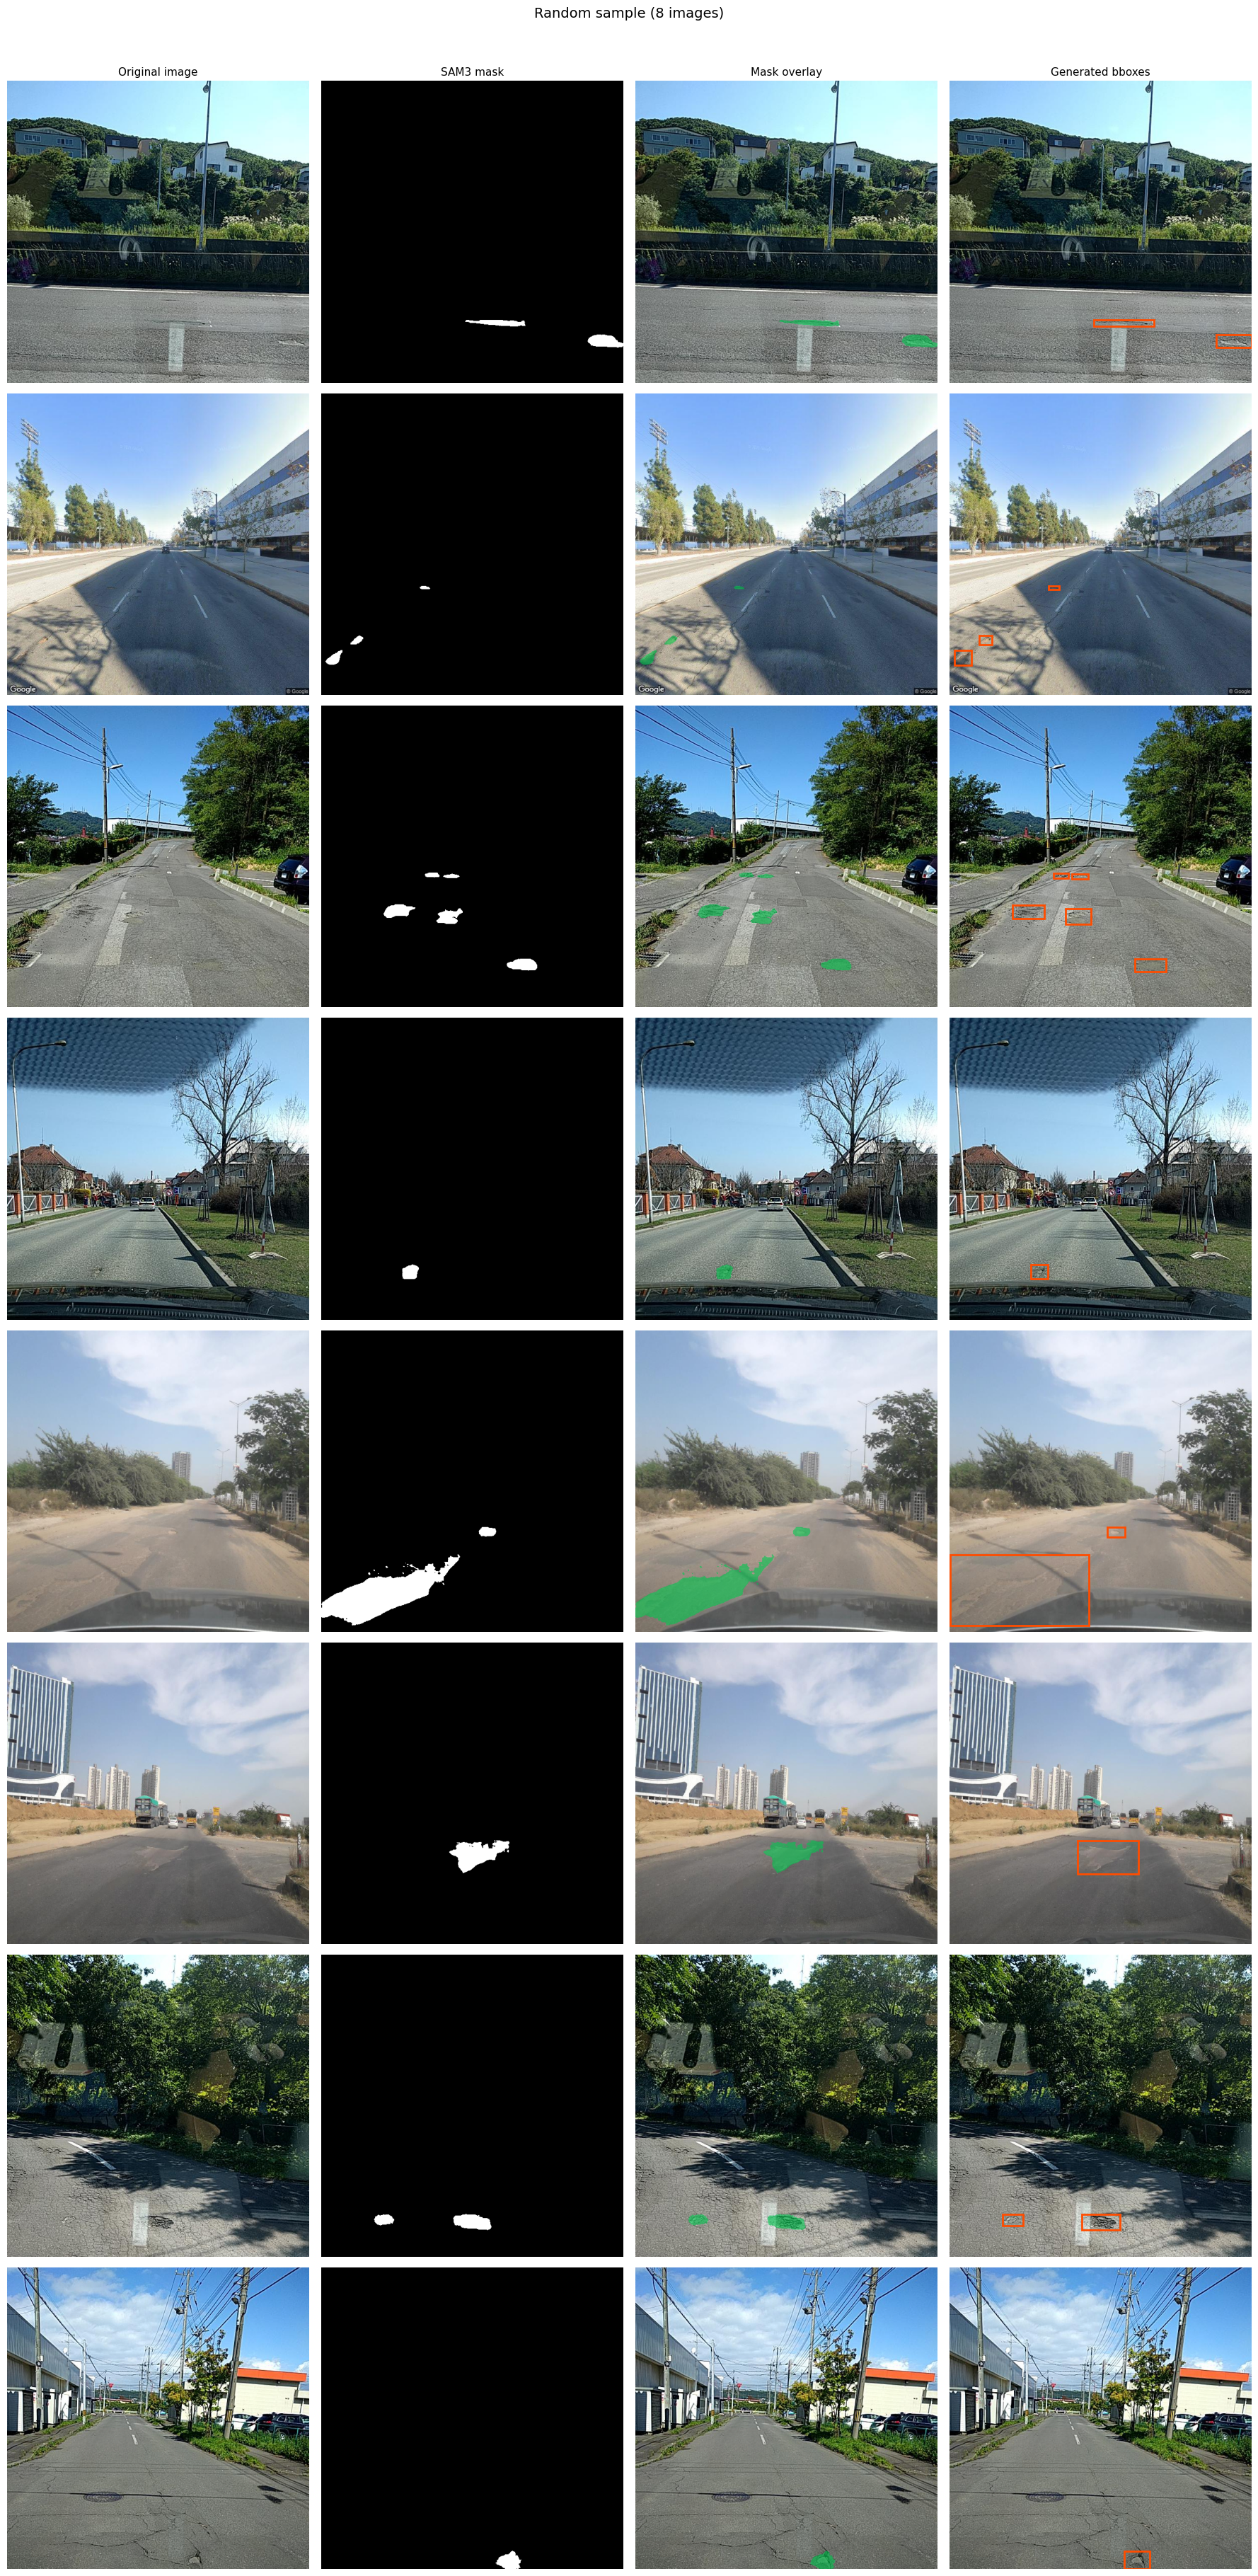

In [2]:
def plot_examples(samples: list, title: str = ""):
    """
    samples: list of (stem, decision)
    Shows 4 panels per row: image | mask | overlay | bboxes
    """
    n = len(samples)
    fig, axes = plt.subplots(n, 4, figsize=(18, 4.5 * n))
    if n == 1:
        axes = [axes]

    if title:
        fig.suptitle(title, fontsize=14, y=1.01)

    col_titles = ["Original image", "SAM3 mask", "Mask overlay", "Generated bboxes"]
    for ax, t in zip(axes[0], col_titles):
        ax.set_title(t, fontsize=11)

    for row_axes, (stem, decision) in zip(axes, samples):
        img_bgr = cv2.imread(str(IMG_DIR / f"{stem}.jpg"))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]

        mask_path = find_mask(stem, decision)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        # mask overlay: green channel highlight
        overlay = img_rgb.copy()
        overlay[mask_resized > 127] = (
            overlay[mask_resized > 127] * 0.4 + np.array([0, 200, 80]) * 0.6
        ).clip(0, 255).astype(np.uint8)

        bboxes = read_yolo_bboxes(BBOX_GEN_DIR / f"{stem}.txt")

        # panel 0: original
        row_axes[0].imshow(img_rgb)
        row_axes[0].set_ylabel(f"{stem}\n({decision.replace('segmentation_', '')})", fontsize=8)

        # panel 1: mask
        row_axes[1].imshow(mask_resized, cmap="gray")

        # panel 2: overlay
        row_axes[2].imshow(overlay)

        # panel 3: image + bboxes
        row_axes[3].imshow(img_rgb)
        for cx, cy, bw, bh in bboxes:
            x0 = (cx - bw / 2) * w
            y0 = (cy - bh / 2) * h
            rect = patches.Rectangle(
                (x0, y0), bw * w, bh * h,
                linewidth=2, edgecolor=(1.0, 0.3, 0.0), facecolor="none"
            )
            row_axes[3].add_patch(rect)

        for ax in row_axes:
            ax.axis("off")

    plt.tight_layout()
    plt.show()


# ── draw N random examples ────────────────────────────────────────────────────
N = 8
random.seed(2)
sample = random.sample(catalogue, k=min(N, len(catalogue)))
plot_examples(sample, title=f"Random sample ({N} images)")

## Filter by dataset / country

Pick a prefix (e.g. `Japan`, `India`, `Norway`, `Czech`, `United_States`, `China_Drone`, `China_MotorBike`) to inspect a specific subset.

Japan: 990 examples available


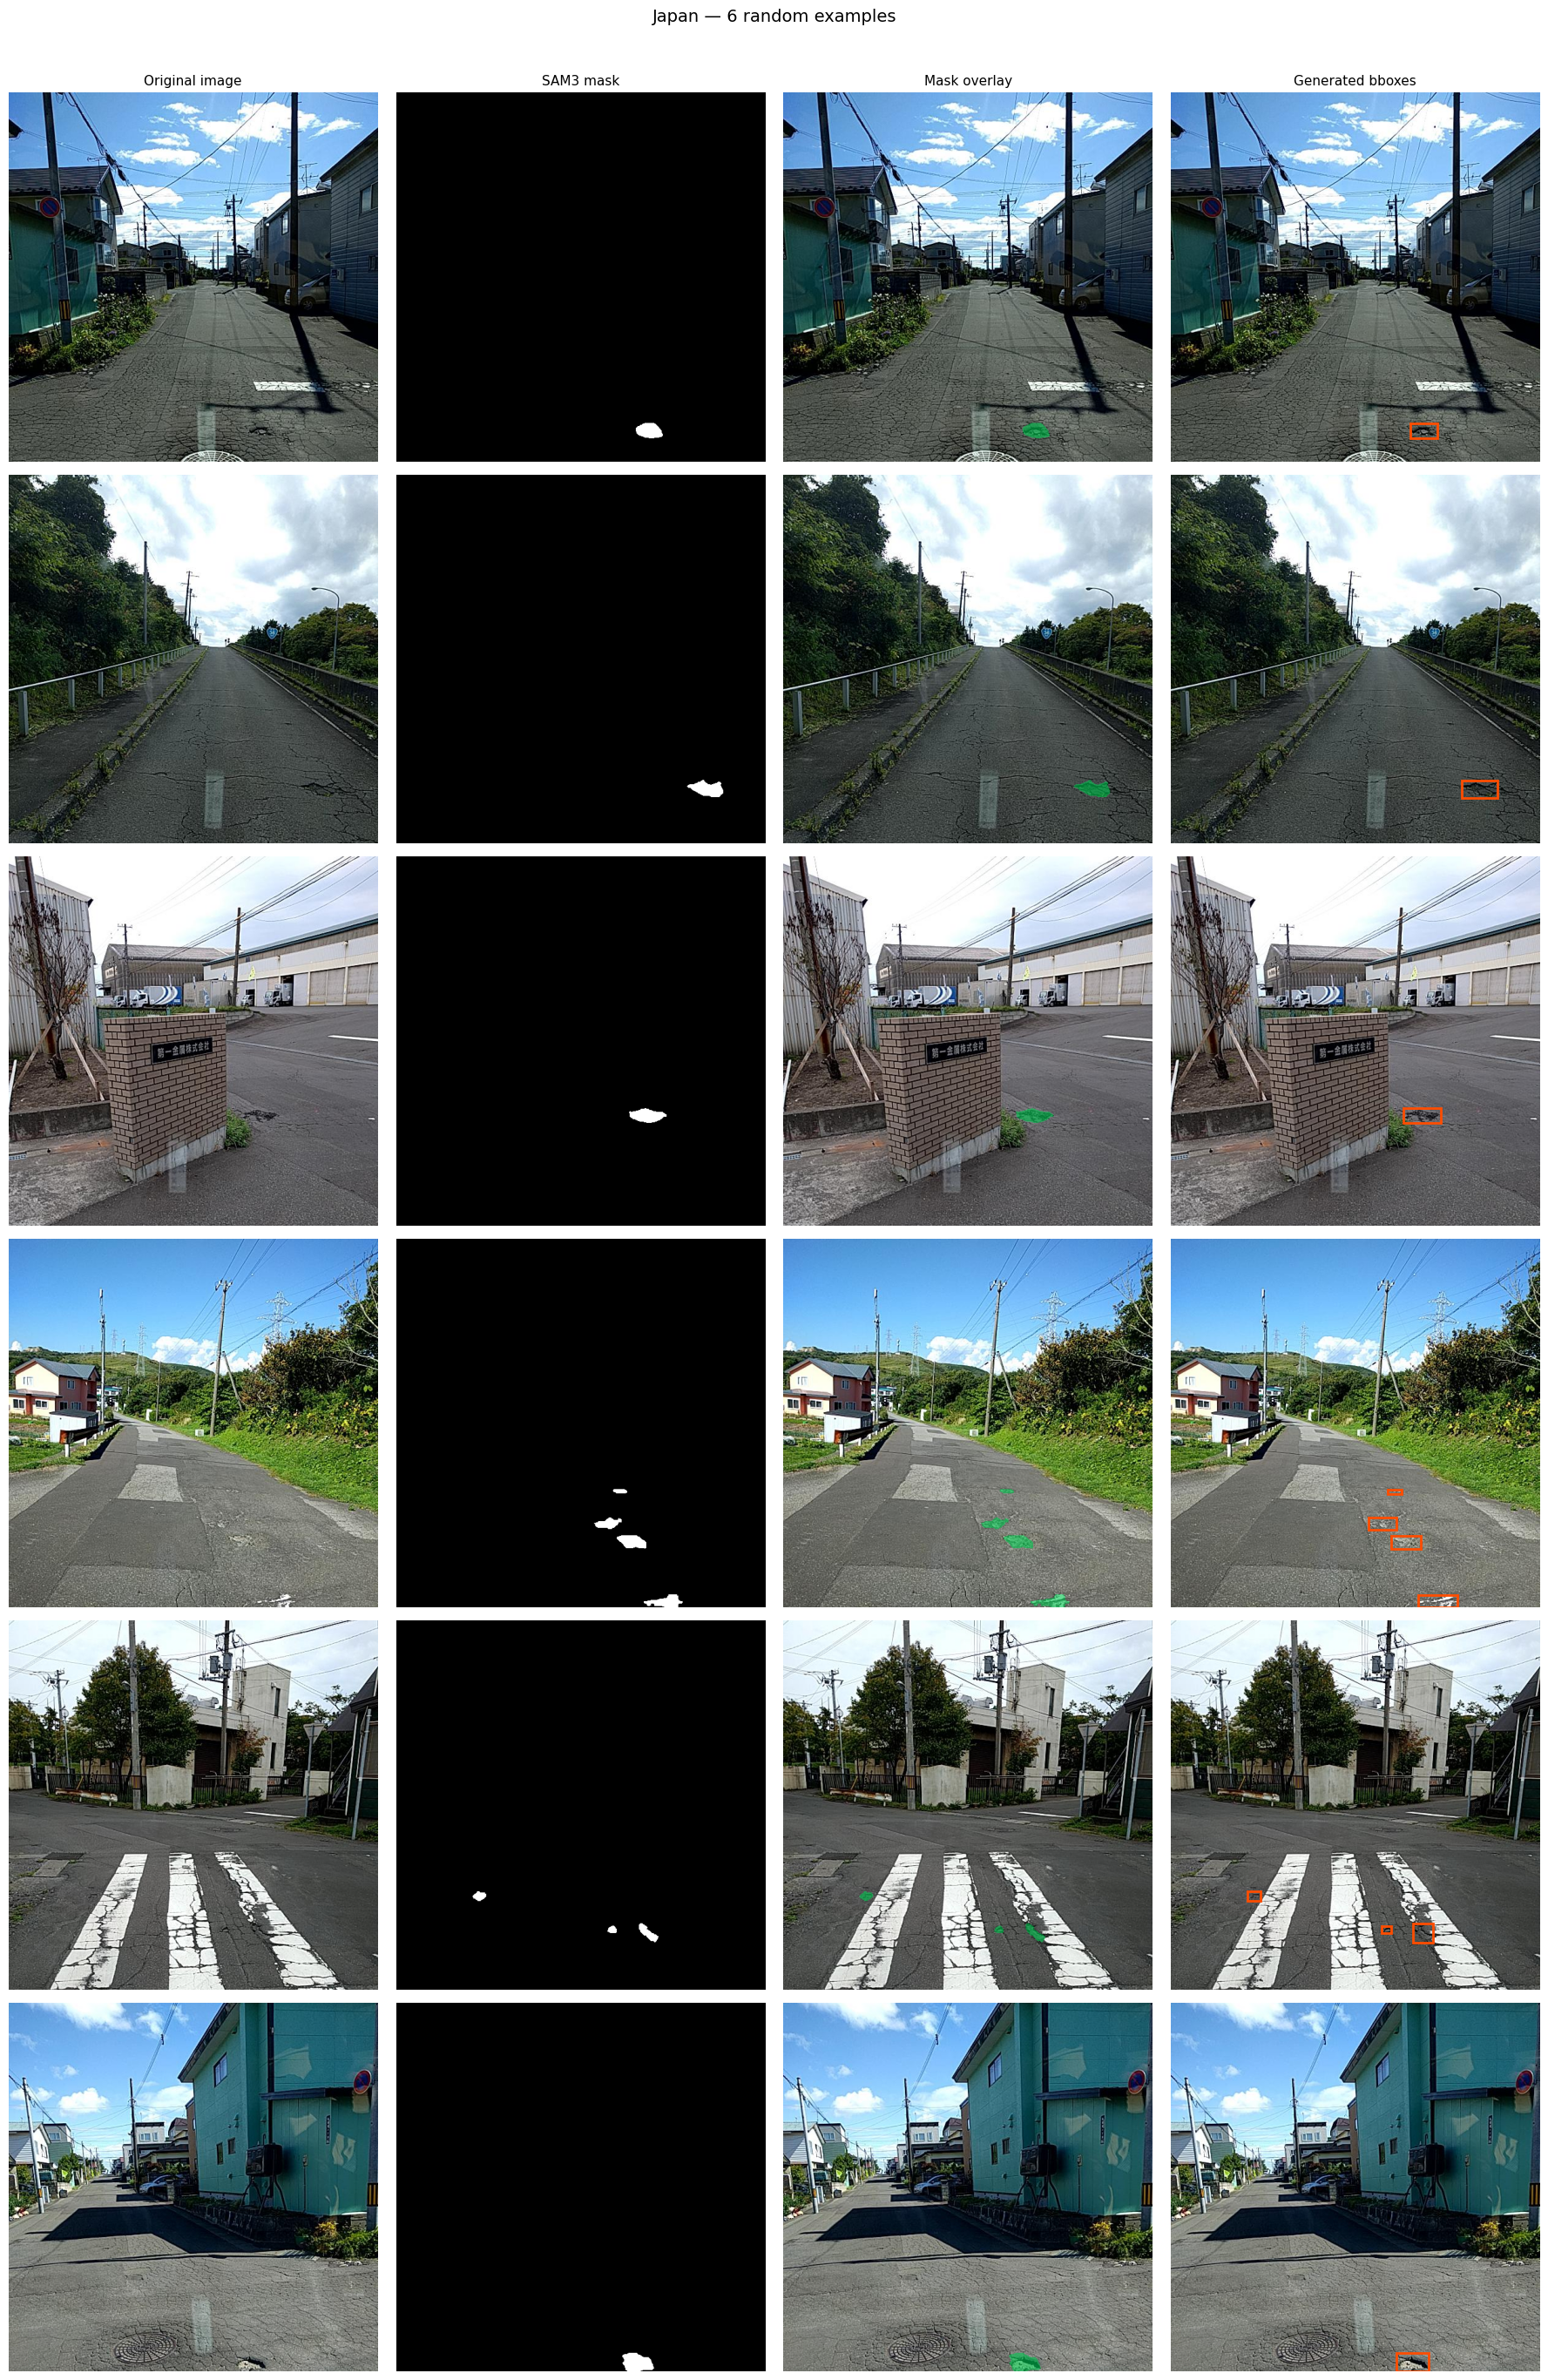

In [3]:
PREFIX = "Japan"   # change to any prefix
N_FILTER = 6

subset = [(s, d) for s, d in catalogue if s.startswith(PREFIX)]
print(f"{PREFIX}: {len(subset)} examples available")

random.seed(0)
sample_filtered = random.sample(subset, k=min(N_FILTER, len(subset)))
plot_examples(sample_filtered, title=f"{PREFIX} — {N_FILTER} random examples")

## Images with multiple bboxes

Show only images where the mask produced more than one bounding box (multiple connected components).

Images with multiple bboxes: 630


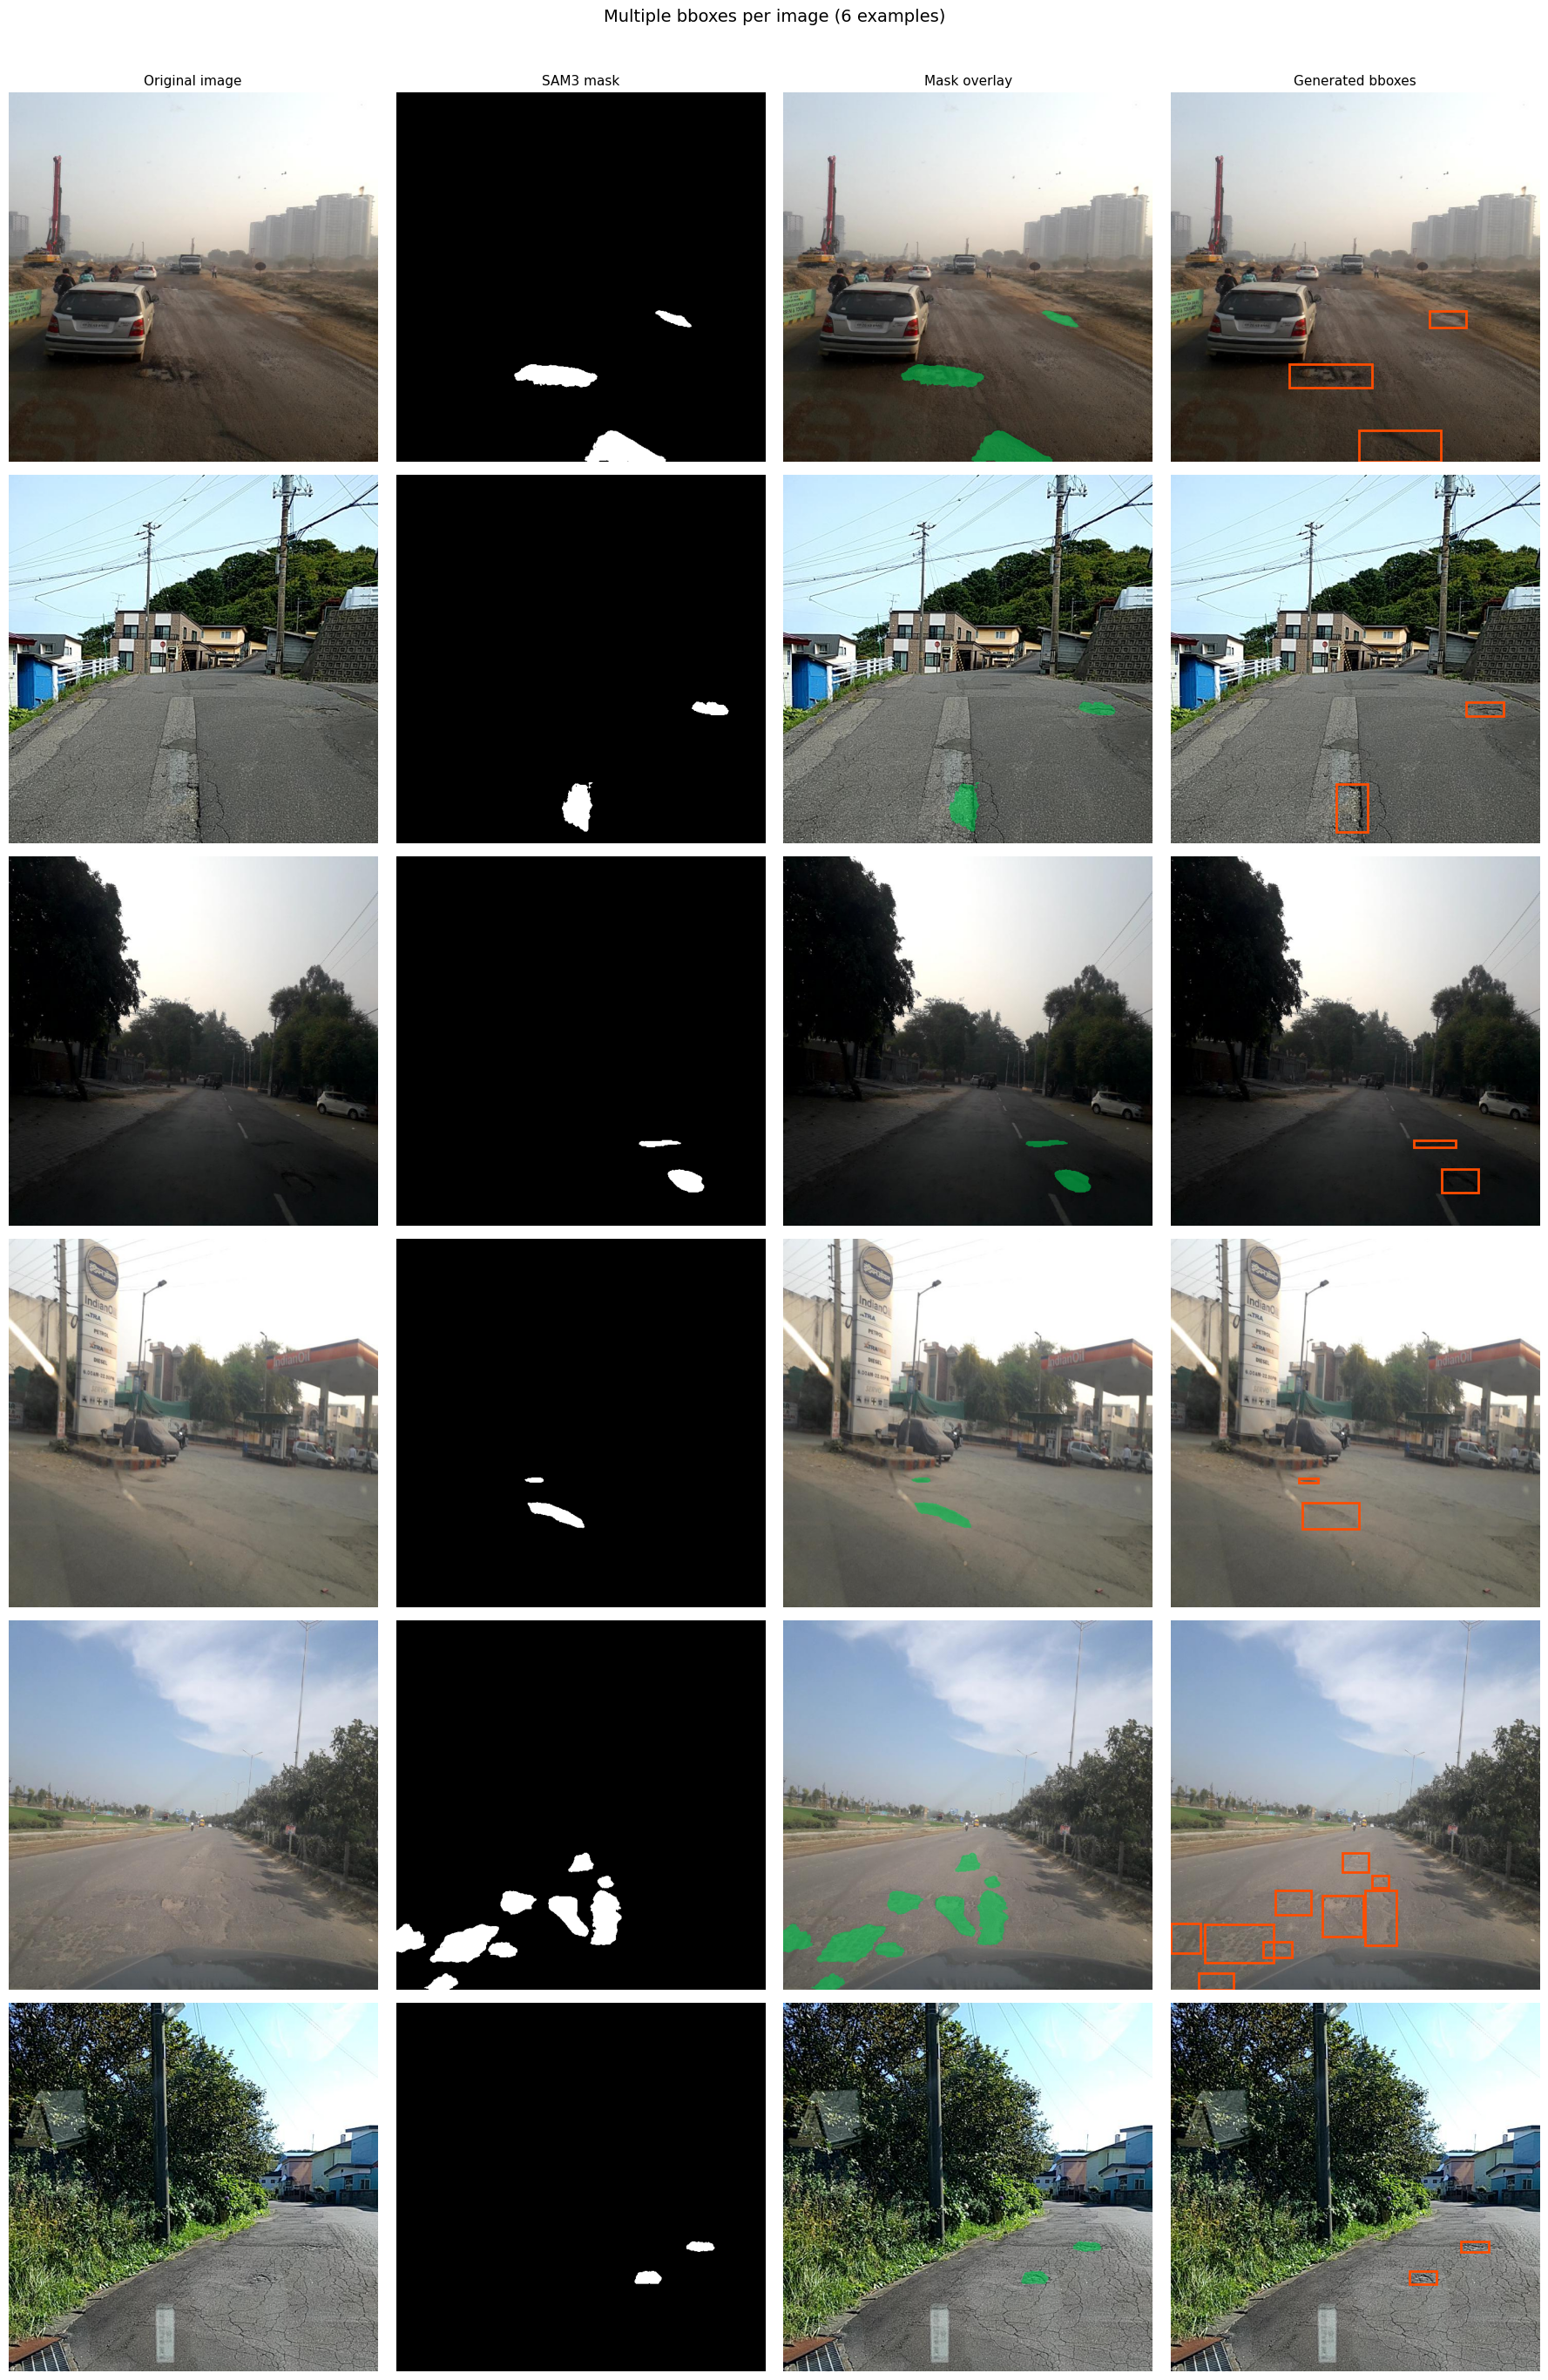

In [16]:
N_MULTI = 6

multi = [
    (s, d) for s, d in catalogue
    if len(read_yolo_bboxes(BBOX_GEN_DIR / f"{s}.txt")) > 1
]
print(f"Images with multiple bboxes: {len(multi)}")

random.seed(7)
sample_multi = random.sample(multi, k=min(N_MULTI, len(multi)))
plot_examples(sample_multi, title=f"Multiple bboxes per image ({N_MULTI} examples)")

## Dataset breakdown

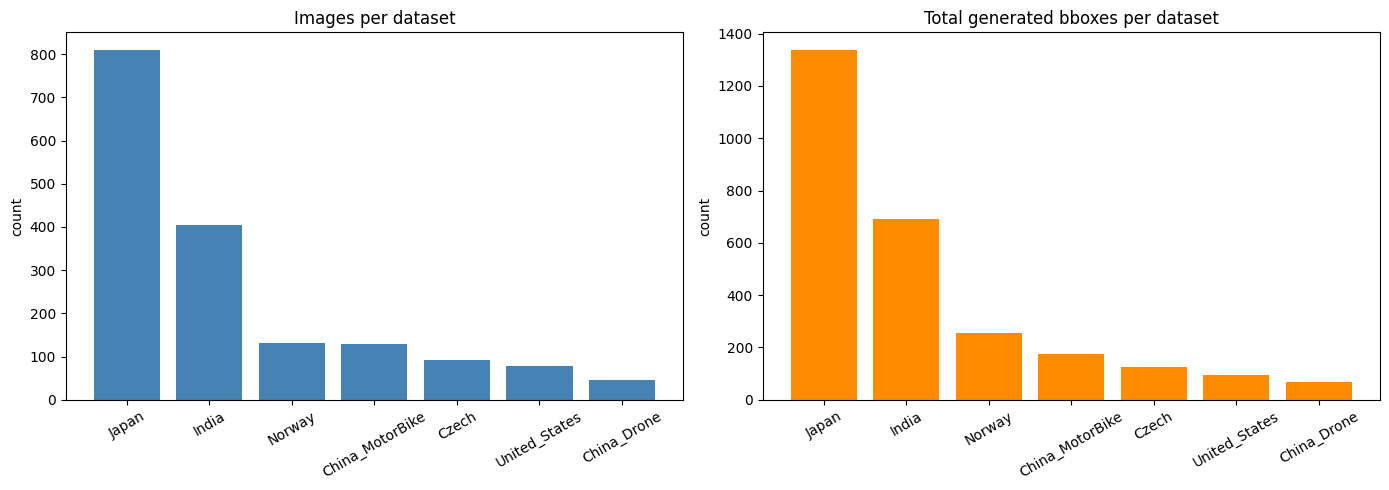


Summary:
Dataset                Images   BBoxes  Avg/img
Japan                     810     1338     1.65
India                     404      692     1.71
Norway                    131      255     1.95
China_MotorBike           129      174     1.35
Czech                      91      127     1.40
United_States              77       93     1.21
China_Drone                45       68     1.51


In [7]:
from collections import Counter

PREFIXES = ["Japan", "India", "Norway", "Czech", "United_States", "China_Drone", "China_MotorBike"]

def get_prefix(stem):
    for p in PREFIXES:
        if stem.startswith(p):
            return p
    return "Other"

counts = Counter(get_prefix(s) for s, _ in catalogue)
bbox_counts = Counter()
for stem, _ in catalogue:
    n = len(read_yolo_bboxes(BBOX_GEN_DIR / f"{stem}.txt"))
    bbox_counts[get_prefix(stem)] += n

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = sorted(counts, key=counts.get, reverse=True)
axes[0].bar(labels, [counts[l] for l in labels], color="steelblue")
axes[0].set_title("Images per dataset")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(labels, [bbox_counts[l] for l in labels], color="darkorange")
axes[1].set_title("Total generated bboxes per dataset")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"{'Dataset':<20} {'Images':>8} {'BBoxes':>8} {'Avg/img':>8}")
for l in labels:
    n_img = counts[l]
    n_bbox = bbox_counts[l]
    print(f"{l:<20} {n_img:>8} {n_bbox:>8} {n_bbox/n_img:>8.2f}")